In [3]:
import numpy as np  
import pandas as pd  
import seaborn as sns   
import matplotlib.pyplot as plt    
import warnings 
warnings.filterwarnings('ignore')

In [6]:
df=pd.read_csv(r'E:\mlproject\archive/StudentsPerformance.csv')
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [9]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [10]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [14]:
df.rename(columns={'race/ethnicity':'race'},inplace=True)

In [17]:
df['Total score']=df['math score']+ df['reading score'] + df['writing score']
df.head()

,gender,race,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [18]:
categorical_columns = [col for col in df.columns if df[col].dtype=='O']
numerical_column = [col for col in df.columns if df[col].dtype !='O']

print('Total len for categorical columns',len(categorical_columns),categorical_columns)
print('Total length for numerical column ',len(numerical_column),numerical_column)

Total len for categorical columns 5 ['gender', 'race', 'parental level of education', 'lunch', 'test preparation course']
Total length for numerical column  4 ['math score', 'reading score', 'writing score', 'Total score']


In [ ]:
# from sklearn.preprocessing import LabelEncoder
# from sklearn.compos`e import ColumnTransformer   


In [20]:
df['average_score']=round(df['Total score']/3,2)
df.head()

,gender,race,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.67
1,female,group C,some college,standard,completed,69,90,88,247,82.33
2,female,group B,master's degree,standard,none,90,95,93,278,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.33
4,male,group C,some college,standard,none,76,78,75,229,76.33


In [21]:
full_marks = df[df['average_score']==100]
full_marks

,gender,race,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total score,average_score
458,female,group E,bachelor's degree,standard,none,100,100,100,300,100.0
916,male,group E,bachelor's degree,standard,completed,100,100,100,300,100.0
962,female,group E,associate's degree,standard,none,100,100,100,300,100.0


In [22]:
reading_full_marks = df[df['reading score']==100]['average_score'].count()
writing_full_marks =df[df['writing score']==100]['average_score'].count() 
math_full_marks = df[df['math score']==100]['average_score'].count()

In [23]:
print('Number of students with full marks in reading : ',reading_full_marks)
print('Number of students with full marks in writing : ',writing_full_marks) 
print('Number of students with full marks in math score : ',math_full_marks)

Number of students with full marks in reading :  17
Number of students with full marks in writing :  14
Number of students with full marks in math score :  7


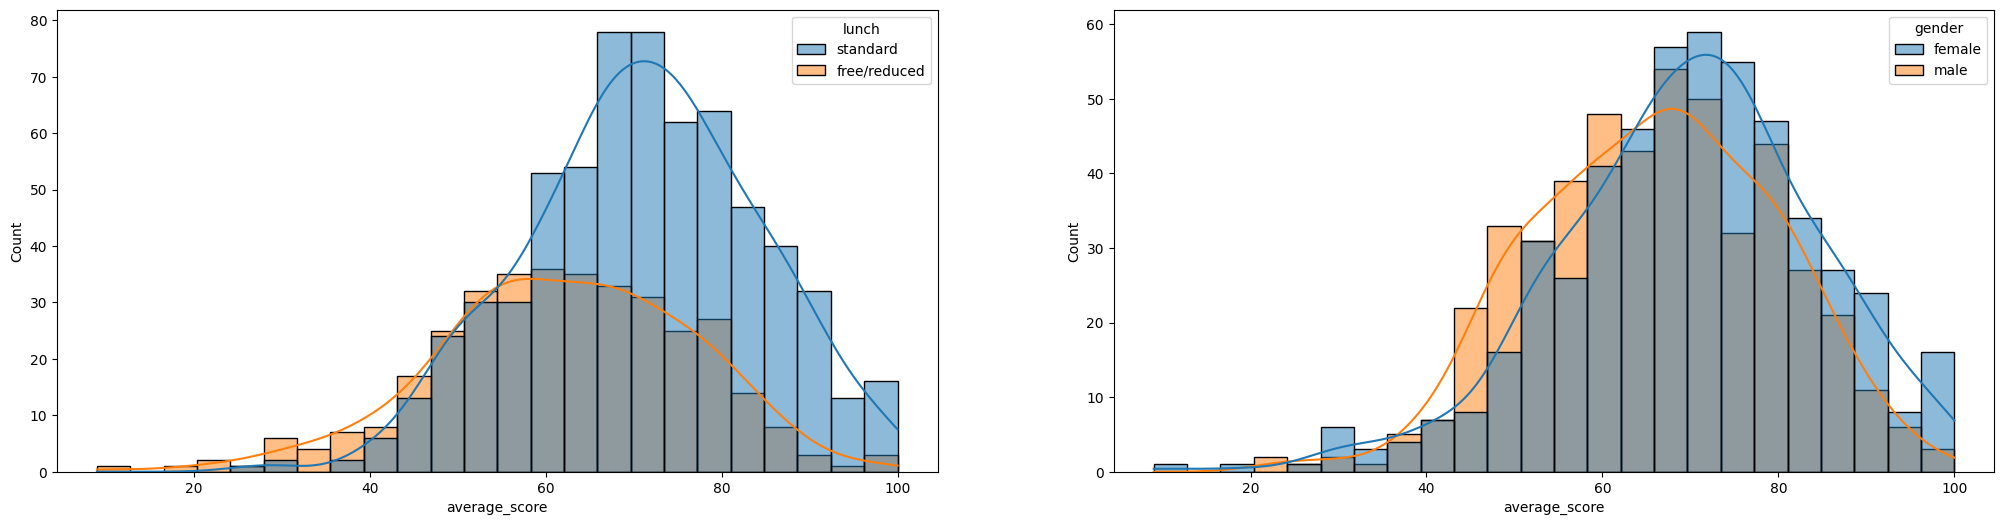

In [26]:
plt.subplots(1,2,figsize=(25,6))
plt.subplot(121)
sns.histplot(data=df,x='average_score',kde=True,hue='lunch')
plt.subplot(122)
sns.histplot(data=df,x='average_score',kde=True,hue='gender')
plt.show()